<div style="background: linear-gradient(135deg, #1e293b 0%, #0f172a 100%); padding: 30px; border-radius: 8px; margin-bottom: 25px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1);">
    <h1 style="color: #f8fafc; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 700; margin: 0; font-size: 2.2em; letter-spacing: -0.5px;"> Procesamiento global de datos PISA-OECD 🌍
</h1>
    <p style="color: #94a3b8; font-family: 'Segoe UI', sans-serif; margin: 8px 0 0 0; font-size: 1.1em;">Obtención de una muestra representativa global </p>
    
</div>

# 📋 Descripción  

Este cuaderno engloba la problematica de obtener una muestra representativa de todos los datos pisa que permita realizar un estudio riguroso del marco contextual para los informes PISA 2022.

**Seleccion de variables : Índices Derivados PISA 2022**


Para evitar la multicolinealidad y la redundancia de procesar más de 1.000 variables presentes en los informes PISA, se utilizarán los **índices derivados** estandarizados por la OCDE. 

Se resumen y agrupan de la siguiente forma:

* **1. Contexto Socioeconómico y Familiar (Estudiante):** Constructos centrados en las condiciones socioeconómicas, culturales y educativas del hogar, esenciales para modelar la equidad educativa.

* **2. Actitud y Dimensión Psicológica:** Métricas relativas a la disposición, motivación y percepciones cognitivo-emocionales del alumno hacia el aprendizaje de las matemáticas .

* **3. Clima Escolar y Bienestar:** Indicadores sobre la percepción del entorno del centro, las relaciones interpersonales y la seguridad desde la perspectiva de los estudiantes.

* **4. Factores Estructurales del Centro (Director):** Variables agregadas del cuestionario de colegio orientadas a evaluar los recursos materiales, la dotación de personal y las condiciones organizativas.


Variables presentes en `STU_QQQ`

**IDs y variables estructurales**

| Columna | Tipo | Significado |
|---|---|---|
| `CNT` | Categórica (String) | Código del País (3 letras). |
| `STRATUM` | Categórica (String) | Estrato de diseño muestral original. |
| `CNTSCHID` | ID (Numérico) | Identificador único de la escuela. |
| `CNTSTUID` | ID (Numérico) | Identificador único del estudiante. |
| `W_FSTUWT` | Peso (Float) | Peso original del estudiante (Ponderación). |

**Índices de Contexto Socioeconómico y Familiar**

| Columna | Tipo | Significado |
|---|---|---|
| `ESCS` | Índice (Continuo) | Índice de Estatus Económico, Social y Cultural. |
| `HISEI` | Índice (Continuo) | Índice más alto de estatus ocupacional de los padres. |
| `PAREDINT` | Numérico (Discreto) | Años máximos de escolaridad de los padres. |
| `HOMEPOS` | Índice (Continuo) | Índice de posesiones en el hogar. |
| `WEALTH` | Índice (Continuo) | Índice de riqueza familiar. |
| `CULTPOSS` | Índice (Continuo) | Posesiones culturales en el hogar. |
| `HEDRES` | Índice (Continuo) | Recursos educativos en el hogar. |
| `ICTRES` | Índice (Continuo) | Recursos TIC en el hogar. |

**Índices Psicológicos y Actitud hacia las Matemáticas**
| Columna | Tipo | Significado |
|---|---|---|
| `ANXMAT` | Índice (Continuo) | Ansiedad hacia las matemáticas. |
| `MATHEFF` | Índice (Continuo) | Autoeficacia en matemáticas. |
| `MATHINT` | Índice (Continuo) | Interés por las matemáticas. |
| `MATHBEH` | Índice (Continuo) | Comportamientos de aprendizaje en matemáticas. |

**Índices de Clima Escolar y Bienestar (Perspectiva Alumno)**
| Columna | Tipo | Significado |
|---|---|---|
| `BELONG` | Índice (Continuo) | Sentido de pertenencia al centro escolar. |
| `BULLY` | Índice (Continuo) | Índice de exposición al acoso escolar. |
| `DISCLIMA` | Índice (Continuo) | Clima disciplinario en las clases de matemáticas. |
| `TEACHSUP` | Índice (Continuo) | Apoyo percibido del profesorado. |

**Variable Objetivo (Target - Matemáticas)**
| Columna | Tipo | Significado |
|---|---|---|
| `PV1MATH` a `PV10MATH` | Objetivo (Float) | Valores Plausibles (1-10) en competencia Matemática. |

In [1]:
#TODO poner las variables presentes en SCH

In [5]:
import sys
import os
import gc

#Se indica la ruta del workspace principale (Dos niveles atras)
sys.path.append(os.path.abspath('../../'))

#Se indica la comprobacion de cambio de librerias externas
%load_ext autoreload
%autoreload 2

In [ ]:

import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import Ridge

# Lectura inicial de los datos

Para la lectura de datos, en vez de el metodo de pandas *read_sas* emplearemos [*pyreadstat*](https://github.com/Roche/pyreadstat/tree/master#reading-files) que presenta una mejor API para el manjo de datos SAS obteniendo el dataframe y sus metadatos

Realizamos la lectura de los metadatos, para obtener el nombre e informacion de las columnas 

In [10]:
ruta_datos_estudiante = '../../data/raw/CY08MSP_STU_QQQ.SAS7BDAT'
ruta_datos_intermedios ='../../data/intermediate'

In [11]:
#Realizamos la lectura de los datos de interes
df, meta = pyreadstat.read_sas7bdat(ruta_datos_estudiante, metadataonly=True)

print(f'Numero de filas: {meta.number_rows} \nNumero de columnas: {meta.number_columns}')

Numero de filas: 613744 
Numero de columnas: 1278


In [36]:
#Se definen las columas utiles para realizar el submuestreo
basic_cols = ['CNT', 'CNTSCHID', 'STRATUM', 'W_FSTUWT','SENWT']

In [37]:
#TODO cambiar nombre : columnas_muestra, por columnas_derivadas

In [38]:
#Se definen los indices derivados utiles para el estudio global de los datos de estudiantes
columnas_muestra_estudiantes = [
    
    # IDs y Pesos base
    'CNT', 'STRATUM', 'CNTSCHID', 'CNTSTUID', 'W_FSTUWT',
    
    # Contexto Socioeconómico y Familiar
    'ESCS', 'HISEI', 'PAREDINT', 'HOMEPOS', 'WEALTH', 
    'CULTPOSS', 'HEDRES', 'ICTRES',
    
    # Actitud y Psicología
    'ANXMAT', 'MATHEFF', 'MATHINT', 'MATHBEH',
    
    # Clima Escolar (Alumno)
    'BELONG', 'BULLY', 'DISCLIMA', 'TEACHSUP',
    
]

In [39]:
# columnas_target = [f'PV{i}MATH' for i in range(1, 11)]

In [40]:
#Se definen los indices derivados útiles para los datos de los colegios

columnas_derivadas_colegios = [
    # IDs y Pesos base
    'CNT', 'STRATUM', 'CNTSCHID',

    #Cuestionario de Centro
    'STRATIO', 'PROPMATH', 'SCHLCLI', 'EDUSHORT', 'STAFFSHORT'
]

**Lectura de las columnas seleccionedas para realizar el subconjunto**

In [41]:
df_basic, meta_basic = pyreadstat.read_sas7bdat(
    ruta_datos_estudiante, 
    usecols=basic_cols
)

In [43]:
df_basic.shape

(613744, 5)

In [44]:
df_basic.head()

,CNT,CNTSCHID,STRATUM,W_FSTUWT,SENWT
0,ALB,800282.0,ALB03,3.15874,0.55561
1,ALB,800115.0,ALB03,4.34524,0.76431
2,ALB,800242.0,ALB01,7.83860,1.37877
3,ALB,800245.0,ALB08,8.49148,1.49361
4,ALB,800285.0,ALB03,3.70957,0.65249


Las combinaciones por cada alumno registrado por los informes de una escuela viene representado por la siguiente combinacion:


 $$Alumno_n= CNT + CNTSCHID + STRATUM $$

De este modo, si una escuela registrara 10 alumnos, todos ellos compartirían el mismo código. Dado que el objetivo en esta etapa es conservar los valores únicos de cada colegio según su país, colegio y estrato, se realizará una eliminación de duplicados (drop_duplicates) basada en la combinación de estas tres variables. Así, se garantiza que cada centro educativo por país figure una sola vez para poder realizar el submuestreo

In [45]:
#Nos quedamos con escuelas únicas, eliminamos ducplicados enteros
escuelas_unicas=df_basic.drop_duplicates(subset=['CNT','CNTSCHID','STRATUM'])

In [46]:
escuelas_unicas.shape

(21629, 5)

# 🔽 Submuestreo global

In [47]:
#TODO generar funcion para establecer semilla

# Porcentaje de los datos de la submuestra
fracion = 0.20 

In [48]:
total_escuelas=escuelas_unicas.groupby('CNT')
grupos_escuelas = escuelas_unicas.groupby(['CNT','STRATUM'])

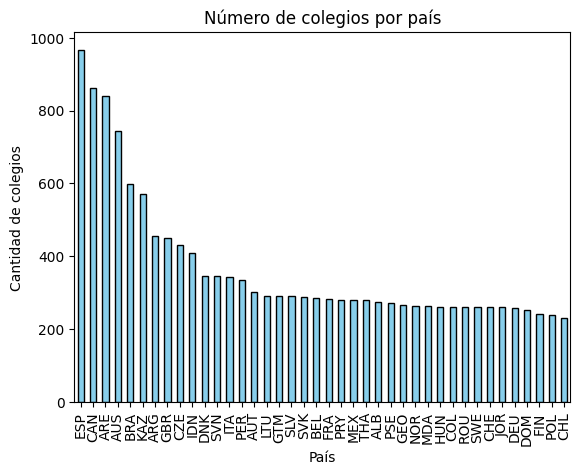

In [49]:
escuelas_unicas.groupby('CNT').size().sort_values(ascending=False).head(40).plot(kind='bar', color='skyblue', edgecolor='black')

# Añadimos títulos para que se entienda mejor
plt.title('Número de colegios por país')
plt.xlabel('País')
plt.ylabel('Cantidad de colegios')

# Esto muestra la gráfica en tu pantalla
plt.show()

In [50]:
grupos = escuelas_unicas.groupby(['CNT', 'STRATUM'])

In [51]:
grupos.size()

CNT  STRATUM
ALB  ALB01      25
     ALB02       5
     ALB03      65
     ALB04      15
     ALB05      38
                ..
VNM  VNM11      26
     VNM12      29
     VNM13       1
     VNM14       4
     VNM15       2
Length: 1014, dtype: int64

In [52]:
#TODO Mejorar redaccion de los datos encontrados

Al analizar el gráfico de barras, destaca significativamente que España (ESP) es uno de los países con mayor volumen de centros educativos en la muestra. Visualmente, supera incluso a países con mayor densidad demográfica, lo que evidencia que el dataset cuenta con una representación notablemente más alta para este territorio en comparación con el resto.

Esta anomalía visual se debe a que España aplica un oversampling (sobremuestra) en este tipo de evaluaciones internacionales: cada una de sus 17 Comunidades Autónomas financia y exige su propia muestra completa para obtener resultados estadísticamente válidos a nivel regional. Al sumarse todas estas muestras independientes, el volumen total de colegios se multiplica exponencialmente en el dataset global.

In [53]:
#Dataframe intermedio donde se encuentran almacenadas las escuelas divididas por pais y por estrato
df_groups =grupos.size().reset_index(name='total_escuelas')

**_Ceiling_** 

Redondeo hacia arriba

Al calcular la cantidad de escuelas a seleccionar dentro de cada estrato (su 20%), se debe usar una funcion de redondeo hacia arriba para evitar que estratos con pocas escuelas se queden a 0

In [54]:
#Garantizamos que cada estrato tenga representación en la submuestra
df_groups['n_submuestra'] = np.ceil(df_groups['total_escuelas']*fracion).astype(int)

**_Limite de seguridad_** 

Para asegurar los pares de varianza, si el estrato original cuenta con 2 o más escuelas, se deben seleccionar como mínimo 2 escuelas de dicho estrato, aunque sobrepasemos el limite del 20% de la submuestra
.

In [55]:
df_groups['n_submuestra']=np.where(
    (df_groups['total_escuelas']>=2) & (df_groups['n_submuestra'] <2), #Condicion 
    2, #Valor imputado si se cumple
    df_groups['n_submuestra'] #Valor si no se cumple
)

**_Factor de inflacion_** 

El factor de inflación es un multiplicador que se utilizará para reajustar el peso de los alumnos (muestras) por consecuencia de realizar la sumbuestra

Cada estudiante representado en los datos PISA tiene un peso  ($W_{FSTUWT}$) indicando cuantos alumnos del total representa. Al realizar submuestreo y eliminar un porcentaje de los datos, los estudiantes que quedan pierden poder de representación (La ponderaciónya no sería exacta para los datos que tenemos). El factor de inflación "infla"  el peso de los alumnos obtenidos para que representen al resto de compañeros perdidos en el submuestreo.


<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  <strong style="display: block; margin-bottom: 6px; font-size: 1.1em;">
    💡 Calculo por estrato
  </strong>
   No todos los estratos terminarán teniendo exactamente un 20% de selección. El factor de inflación se calcula de forma dinámica y personalizada para cada estrato
</div>


$$\text{Factor de Inflación} = \frac{N_{\text{escuelas originales en el estrato}}}{N_{\text{escuelas seleccionadas en el estrato}}}$$

In [56]:
df_groups['factor_inflacion']=df_groups['total_escuelas']/df_groups['n_submuestra']

In [57]:
df_groups.set_index(['CNT','STRATUM'])

total_escuelas  n_submuestra  factor_inflacion
CNT STRATUM                                                
ALB ALB01                25             5          5.000000
    ALB02                 5             2          2.500000
    ALB03                65            13          5.000000
    ALB04                15             3          5.000000
    ALB05                38             8          4.750000
...                     ...           ...               ...
VNM VNM11                26             6          4.333333
    VNM12                29             6          4.833333
    VNM13                 1             1          1.000000
    VNM14                 4             2          2.000000
    VNM15                 2             2          1.000000

[1014 rows x 3 columns]

## Selección de escuelas

In [58]:
#Creamos los diccionarios que contendran las escuelas seleccionadas y los factores de inflacion asociados
escuelas_seleccionadas_set = set()
factores_dict = {}

In [59]:
#Para realizar la iteración de forma mas rápida, convertimos en un diccionario el dataframe de los grupos encontrados
#La clave del diccionario sera la tupla de los indices del dataframe, y los valores el resto de elementos del dataframe
groups_dict = df_groups.set_index(['CNT','STRATUM']).to_dict('index')

In [60]:
primera_clave = next(iter(groups_dict))
primer_valor = groups_dict[primera_clave]
print(f"Clave: {primera_clave} | Valor: {primer_valor}")

Clave: ('ALB', 'ALB01') | Valor: {'total_escuelas': 25, 'n_submuestra': 5, 'factor_inflacion': 5.0}


In [61]:
#Inicializamos el bucle para selecionar las escuelas de cada estrato que conformaran la submuestra

for (pais,estrato), grupo in grupos:

    #Almacenamiento de los datos del estrato
    datos_estrato = groups_dict[(pais,estrato)]
    n_colegios_elegidos = datos_estrato['n_submuestra']

    #Selecion de la muestra dentro del estrato selecioado
    #TODO Quitar lo de random state cuando tengas la funcion de la semilla
    muestra = grupo.sample(n=n_colegios_elegidos,random_state=42)

    #Actualizamos el diccionario con la clave (pais,estrato) y valor el ID del colegio seleccionado
    #Obteniendo asi 3 identidicadores inequivocos por colegio
    for colegio_id in muestra['CNTSCHID'].values:
        #Nos aseguramos los valors unicos guardado cada tupla de tres en el set
        escuelas_seleccionadas_set.add((pais, estrato, colegio_id))
        
        # Guardamos el factor asociado al estrato
        factores_dict[(pais, estrato)] = datos_estrato['factor_inflacion']


In [62]:
print(f"Numero de escuelas original: {len(escuelas_unicas)}")
print(f"Numero de escuelas selecionadas: {len(escuelas_seleccionadas_set)}")

Numero de escuelas original: 21629
Numero de escuelas selecionadas: 5113


In [63]:
#Se visualiza la forma del set de escuelas selecionadas
list(escuelas_seleccionadas_set)[:5]

[('PRY', 'PRY06', np.float64(60000207.0)),
 ('AUS', 'AUS14', np.float64(3600008.0)),
 ('GEO', 'GEO08', np.float64(26800132.0)),
 ('HKG', 'HKG02', np.float64(34400157.0)),
 ('AUS', 'AUS10', np.float64(3600247.0))]

In [64]:
#Se visualiza la forma del diccionario de factor de inflacion
iterador = iter(factores_dict.items())
clave,valor = next(iterador)
print('Diccionario Factor de inflacion: ')
print(f'Clave: {clave} | Valor: {valor}')

Diccionario Factor de inflacion: 
Clave: ('ALB', 'ALB01') | Valor: 5.0


In [65]:
#TODO Pasar los datos de interes a parqut y gurdarlos en intermediate

In [66]:
#Se realiza una limpieza rápida de la memoria
del df_basic, escuelas_unicas, df_groups
gc.collect()

16565

## Lectura de datos por bloques y ajuste de ponderaciones

Una vez que se han seleccionado las escuelas que conforman nuestra muestra global, se procede a la lectura de los datos mediante bloques (_Chunks_) de tal forma que se evite la sobre carga de memoria.
Al usar la funcion `read_file_in_chunks` de pyreadstat se peirde la capacidad de seleccionar las columnas a leer, por lo que posteriormente, se deberá realizar un filtrado con las columnas de interes para el analisis

Debemos leer los datos de los estudiantes, almacenados en el fichero de datos `CY08MSP_STU_QQQ.SAS7BDAT` y con los mismos identificadores únicos leer los datos de los colegios, almacenados en `CY08MSP_SCH_QQQ.SAS7BDAT` para obtener un dataset submuestreado de los datos de la OECD para el analisis global

**Ajuste de ponderaciones ( Estudiante y senado )**

De las muestras que son seleccionadas, se debe ajustar sus ponderaciones de estudiante

$$W_{\text{FSTUWT, adj}} = W_{\text{FSTUWT}} \times \text{Factor de Inflación} $$


Debido a que no todos los paises tiene la misma cantidad de alumnos, los factores de ponderación por estudiante pueden generar que los modelos se ajusten a los paises con mayor cantidad de estudiantes. Par evitar eso la OECD utiliza la ponderación de senado `SENWT`

<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  <strong style="display: block; margin-bottom: 6px; font-size: 1.1em;">
    💡 Peso de senado
  </strong>
   El peso de senado (<code style="background: rgba(255,255,255,0.15); padding: 2px 6px; border-radius: 4px; font-family: monospace;">SENWT</code>) es una transformación lineal de <code style="background: rgba(255,255,255,0.15); padding: 2px 6px; border-radius: 4px; font-family: monospace;">W_FSTUWT</code> de tal forma que la suma de los pesos de los estudiantes participantes de cada país sume exactamente un valor constante, típicamente 5.000(PISA 2022 Technical Report, p.188), de tal forma que cada pais tenga el mismo peso en un análisis general
</div>

Sin embargo, al realizar la submuestra, la suma de los pesos originales de senado (SENWT) de los estudiantes que fueron selecionados ya no dará 5.000 por país, si no aproximadamente 1.000 y fuctuará entre países dependiendo del tamaño específico de las escuelas que hayan sido seleccionadas al azar en cada región

**La solucion:** se debe crear un peso de senado ajustado en funcion de los pesos de los esrudiantes calculados anteriormente

$$SENWT\_adj_i = W_{FSTUWT\_adj\_i} \times \left( \frac{5000}{\sum W_{FSTUWT\_adj \text{ (del país)}} } \right)$$

Siendo:

$SENWT\_adj_i$ = Peso de senado ajustado a cada estudiante individual

$\sum W_{FSTUWT\_adj \text{ (del país)}}$ =Suma de todos los pesos ponderados de ese pais

$W_{FSTUWT\_adj\_i}$ = Peso ponderado de cada estudiante individual


<table width="100%" style="border:none; text-align:center;">
  <tr>
    <td style="border:none;"><hr></td>
    <td style="border:none; white-space:nowrap; padding:0 10px;"> <strong>Lectura de los datos de los estudiantes<strong>
</td>
    <td style="border:none;"><hr></td>
  </tr>
</table>


In [67]:
#Tamaño de los bloques a leer
chunk_size = 10000
#Array donde almacenaremos los datos temporales filtrados
chunks_filtrados=[]

In [68]:
#Inicializamos el generador que nos permitira leer los datos en bloques
reader = pyreadstat.read_file_in_chunks(
    pyreadstat.read_sas7bdat, 
    ruta_datos_estudiante, 
    chunksize=chunk_size,
    usecols=columnas_muestra_estudiantes
)

In [69]:
#Bucle donde se realizará el filtrado por escuelas seleccionadas

for chunk, meta in reader:

    #Lista de tuplas que contiene la clave para identificar los colegios seleccionados
    chunk['clave_colegio_temp']=list(zip(
        chunk['CNT'],
        chunk['STRATUM'],
        chunk['CNTSCHID']
        ))
    
    #Se almacenan únicamente los datos de las escuelas seleccionadas
    chunk_filtrado = chunk[chunk['clave_colegio_temp'].isin(escuelas_seleccionadas_set)].copy()

    #Si en el chunk se encuentra alguna escuela seleccionada
    if not chunk_filtrado.empty :
        
        #Creamos dentro del dataframe las claves para el dicionario de factor de inflacion
        chunk_filtrado['clave_factor_temp'] = list(zip(
            chunk_filtrado['CNT'],
            chunk_filtrado['STRATUM']
        ))

        #Mapeamos los datos del diccionario de factores mediante la clave generada
        chunk_filtrado['factor_inflacion']=chunk_filtrado['clave_factor_temp'].map(factores_dict)

        #Ajustamos al ponderacion de estudiante
        chunk_filtrado['W_FSTUWT_adj'] = chunk_filtrado['W_FSTUWT']*chunk_filtrado['factor_inflacion']

        #Guardamos el chunk filtrado en la lista general de bloques 
        chunks_filtrados.append(chunk_filtrado)
        

In [70]:
#Unimos todos los bloques individuales en un dataframe 
df_alumnos = pd.concat(chunks_filtrados,ignore_index=True)

In [71]:
#TODO Comentar esto

In [72]:
suma_pesos_pais = df_alumnos.groupby('CNT')['W_FSTUWT_adj'].transform('sum')
df_alumnos['SENWT_adj'] = df_alumnos['W_FSTUWT_adj'] * (5000 / suma_pesos_pais)

In [73]:
#TODO comentar esto

In [74]:
parquet_alumnos = os.path.join(ruta_datos_intermedios, 'pisa_submuestra_estudiantes.parquet')

In [75]:
#Se almacena el dataframe en formato parquet
df.to_parquet(parquet_alumnos, engine='pyarrow', index=False)

**Calculo del porcentaje de la submuestra obtenido**

In [76]:
#Total de datos de la submuestra ( alumnos escogidos )
total_alumnos_muestra = len(df_alumnos)

# #Total de datos originales
total_alumnos_original = meta_basic.number_rows  
porcentaje_real = (total_alumnos_muestra / total_alumnos_original) * 100

print(f"Numero de alumnos originales: {total_alumnos_original}")
print(f"Numero Alumnos seleccionados: {total_alumnos_muestra}")
print(f"Porcentaje de la muestra sobre el total: {porcentaje_real:.2f}%")

Numero de alumnos originales: 613744
Numero Alumnos seleccionados: 146500
Porcentaje de la muestra sobre el total: 23.87%


In [77]:
display(df_alumnos.head())
display(df_alumnos.tail())

,CNT,CNTSCHID,CNTSTUID,STRATUM,BELONG,TEACHSUP,MATHEFF,ANXMAT,PAREDINT,HISEI,ICTRES,HOMEPOS,ESCS,W_FSTUWT,clave_colegio_temp,clave_factor_temp,factor_inflacion,W_FSTUWT_adj,SENWT_adj
0,ALB,800282.0,800001.0,ALB03,-0.2327,1.5558,-1.4413,0.5440,14.5,73.91,4.9507,1.5995,1.1112,3.15874,"(ALB, ALB03, 800282.0)","(ALB, ALB03)",5.0,15.79370,2.837345
1,ALB,800242.0,800003.0,ALB01,NaN,NaN,NaN,NaN,12.0,NaN,0.4307,0.2314,-0.1867,7.83860,"(ALB, ALB01, 800242.0)","(ALB, ALB01)",5.0,39.19300,7.041040
2,ALB,800172.0,800007.0,ALB04,-0.4514,1.5558,2.1409,NaN,16.0,86.72,0.7200,0.3684,1.0855,4.25946,"(ALB, ALB04, 800172.0)","(ALB, ALB04)",5.0,21.29730,3.826069
3,ALB,800040.0,800015.0,ALB03,NaN,NaN,NaN,NaN,16.0,NaN,-1.1745,-0.7675,-0.1699,4.41304,"(ALB, ALB03, 800040.0)","(ALB, ALB03)",5.0,22.06520,3.964023
4,ALB,800123.0,800024.0,ALB06,0.3282,1.5558,0.8876,1.0112,12.0,28.84,-0.0939,-0.1056,-0.8850,5.89072,"(ALB, ALB06, 800123.0)","(ALB, ALB06)",3.5,20.61752,3.703947


,CNT,CNTSCHID,CNTSTUID,STRATUM,BELONG,TEACHSUP,MATHEFF,ANXMAT,PAREDINT,HISEI,ICTRES,HOMEPOS,ESCS,W_FSTUWT,clave_colegio_temp,clave_factor_temp,factor_inflacion,W_FSTUWT_adj,SENWT_adj
146495,UZB,86000071.0,86007478.0,UZB20,1.1471,1.5558,-1.3628,0.5410,16.0,29.16,NaN,-0.3683,-0.3133,52.64530,"(UZB, UZB20, 86000071.0)","(UZB, UZB20)",3.000000,157.935900,1.708753
146496,UZB,86000054.0,86007480.0,UZB18,0.7356,1.5558,-0.3503,-0.4275,16.0,27.91,NaN,-2.5059,-1.2422,60.89640,"(UZB, UZB18, 86000054.0)","(UZB, UZB18)",4.666667,284.183200,3.074659
146497,UZB,86000002.0,86007483.0,UZB23,-0.1965,1.5558,0.6632,1.2353,12.0,30.11,NaN,-1.7700,-1.5660,77.07738,"(UZB, UZB23, 86000002.0)","(UZB, UZB23)",2.000000,154.154760,1.667844
146498,UZB,86000056.0,86007485.0,UZB01,-0.2824,-0.3322,-1.1804,0.8251,16.0,81.92,NaN,-0.9848,0.4218,65.63910,"(UZB, UZB01, 86000056.0)","(UZB, UZB01)",1.000000,65.639100,0.710168
146499,UZB,86000123.0,86007492.0,UZB10,0.7979,1.5558,-1.3703,NaN,16.0,21.24,NaN,-1.0122,-0.7355,65.47339,"(UZB, UZB10, 86000123.0)","(UZB, UZB10)",4.250000,278.261908,3.010594


In [78]:
#Eliminamos las columnas temporales de clave utilizadas anteriormente para los calculos
df_alumnos.drop(['clave_colegio_temp','clave_factor_temp'],axis=1,inplace=True)


<table width="100%" style="border:none; text-align:center;">
  <tr>
    <td style="border:none;"><hr></td>
    <td style="border:none; white-space:nowrap; padding:0 10px;"> <strong>Lectura de los datos de los colegios<strong>
</td>
    <td style="border:none;"><hr></td>
  </tr>
</table>


Dado que los datos en crudo de los colegios pesan menos, al haber una muestra por colegio, no será necesario realizar la lectura por bloques, si no que se utilizará directamente la lectura del archivo SAS indicando los indices derivados de interes definidos anteriormente

In [79]:
print(columnas_derivadas_colegios)

['CNT', 'STRATUM', 'CNTSCHID', 'STRATIO', 'PROPMATH', 'SCHLCLI', 'EDUSHORT', 'STAFFSHORT']


In [80]:
#Lectura de los datos de los coloegios 
df_colegios, meta_sch = pyreadstat.read_sas7bdat(
    '../../data/raw/CY08MSP_SCH_QQQ.SAS7BDAT', 
    usecols=columnas_derivadas_colegios
)

In [81]:
df_colegios.shape

(21629, 7)

In [82]:
df_colegios.info()

<class 'pandas.DataFrame'>
RangeIndex: 21629 entries, 0 to 21628
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CNT         21629 non-null  str    
 1   CNTSCHID    21629 non-null  float64
 2   STRATUM     21629 non-null  str    
 3   STRATIO     17884 non-null  float64
 4   PROPMATH    19189 non-null  float64
 5   STAFFSHORT  17138 non-null  float64
 6   EDUSHORT    19172 non-null  float64
dtypes: float64(5), str(2)
memory usage: 1.3 MB


In [83]:
display(df_colegios.head())
display(df_colegios.tail())

,CNT,CNTSCHID,STRATUM,STRATIO,PROPMATH,STAFFSHORT,EDUSHORT
0,ALB,800001.0,ALB05,16.9351,0.1299,-0.2968,1.2048
1,ALB,800002.0,ALB07,11.4375,0.1875,-1.4551,2.9595
2,ALB,800003.0,ALB06,7.1176,0.1176,0.2833,0.6299
3,ALB,800004.0,ALB05,16.9134,0.1260,-1.4551,1.6863
4,ALB,800005.0,ALB03,11.7407,0.0741,-0.2129,1.2478


,CNT,CNTSCHID,STRATUM,STRATIO,PROPMATH,STAFFSHORT,EDUSHORT
21624,QUR,90100178.0,UKR26,7.6190,0.0952,0.2633,0.4698
21625,QUR,90100179.0,UKR26,3.7674,0.1163,-0.1798,2.1904
21626,QUR,90100180.0,UKR12,12.9855,0.0725,0.0280,0.8339
21627,QUR,90100181.0,UKR21,14.9592,0.1224,0.2633,0.3066
21628,QUR,90100182.0,UKR14,18.7568,0.1081,-1.4551,0.1423



<table width="100%" style="border:none; text-align:center;">
  <tr>
    <td style="border:none;"><hr></td>
    <td style="border:none; white-space:nowrap; padding:0 10px;"> <strong>Unión datos alumnos y colegios<strong>
</td>
    <td style="border:none;"><hr></td>
  </tr>
</table>


Se realiza un merge para unir ambos DataFrames obtenidos mediante las claves unicas de pais, estrato e ID Escuela

In [84]:
df_muestra_global = pd.merge(df_alumnos,
                             df_colegios,
                             on=['CNT','STRATUM','CNTSCHID'],
                             how='left')

In [85]:
df_muestra_global.shape

(146500, 21)

In [86]:
df_muestra_global.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 146500 entries, 0 to 146499
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CNT               146500 non-null  str    
 1   CNTSCHID          146500 non-null  float64
 2   CNTSTUID          146500 non-null  float64
 3   STRATUM           146500 non-null  str    
 4   BELONG            134079 non-null  float64
 5   TEACHSUP          124102 non-null  float64
 6   MATHEFF           112796 non-null  float64
 7   ANXMAT            114071 non-null  float64
 8   PAREDINT          139470 non-null  float64
 9   HISEI             128864 non-null  float64
 10  ICTRES            84138 non-null   float64
 11  HOMEPOS           142629 non-null  float64
 12  ESCS              140451 non-null  float64
 13  W_FSTUWT          146500 non-null  float64
 14  factor_inflacion  146500 non-null  float64
 15  W_FSTUWT_adj      146500 non-null  float64
 16  SENWT_adj         146500 non-nu

In [87]:
display(df_muestra_global.head())
display(df_muestra_global.tail())

,CNT,CNTSCHID,CNTSTUID,STRATUM,BELONG,TEACHSUP,MATHEFF,ANXMAT,PAREDINT,HISEI,...,HOMEPOS,ESCS,W_FSTUWT,factor_inflacion,W_FSTUWT_adj,SENWT_adj,STRATIO,PROPMATH,STAFFSHORT,EDUSHORT
0,ALB,800282.0,800001.0,ALB03,-0.2327,1.5558,-1.4413,0.5440,14.5,73.91,...,1.5995,1.1112,3.15874,5.0,15.79370,2.837345,11.0789,0.1053,-0.0097,-0.2805
1,ALB,800242.0,800003.0,ALB01,NaN,NaN,NaN,NaN,12.0,NaN,...,0.2314,-0.1867,7.83860,5.0,39.19300,7.041040,13.2400,0.1200,0.1683,0.1753
2,ALB,800172.0,800007.0,ALB04,-0.4514,1.5558,2.1409,NaN,16.0,86.72,...,0.3684,1.0855,4.25946,5.0,21.29730,3.826069,8.1296,0.1296,-1.4551,-1.4212
3,ALB,800040.0,800015.0,ALB03,NaN,NaN,NaN,NaN,16.0,NaN,...,-0.7675,-0.1699,4.41304,5.0,22.06520,3.964023,17.4737,0.1474,-0.1776,0.1080
4,ALB,800123.0,800024.0,ALB06,0.3282,1.5558,0.8876,1.0112,12.0,28.84,...,-0.1056,-0.8850,5.89072,3.5,20.61752,3.703947,17.8846,0.0865,-1.4551,-1.4212


,CNT,CNTSCHID,CNTSTUID,STRATUM,BELONG,TEACHSUP,MATHEFF,ANXMAT,PAREDINT,HISEI,...,HOMEPOS,ESCS,W_FSTUWT,factor_inflacion,W_FSTUWT_adj,SENWT_adj,STRATIO,PROPMATH,STAFFSHORT,EDUSHORT
146495,UZB,86000071.0,86007478.0,UZB20,1.1471,1.5558,-1.3628,0.5410,16.0,29.16,...,-0.3683,-0.3133,52.64530,3.000000,157.935900,1.708753,19.0164,0.0984,NaN,-0.4447
146496,UZB,86000054.0,86007480.0,UZB18,0.7356,1.5558,-0.3503,-0.4275,16.0,27.91,...,-2.5059,-1.2422,60.89640,4.666667,284.183200,3.074659,12.4023,0.0575,NaN,0.6299
146497,UZB,86000002.0,86007483.0,UZB23,-0.1965,1.5558,0.6632,1.2353,12.0,30.11,...,-1.7700,-1.5660,77.07738,2.000000,154.154760,1.667844,18.2667,0.0667,NaN,0.4997
146498,UZB,86000056.0,86007485.0,UZB01,-0.2824,-0.3322,-1.1804,0.8251,16.0,81.92,...,-0.9848,0.4218,65.63910,1.000000,65.639100,0.710168,14.7862,0.1034,NaN,-0.2376
146499,UZB,86000123.0,86007492.0,UZB10,0.7979,1.5558,-1.3703,NaN,16.0,21.24,...,-1.0122,-0.7355,65.47339,4.250000,278.261908,3.010594,14.3881,0.0746,NaN,-0.3123


In [88]:
#Se almacena en formato parquet el DataFrame global de la submuestra obtenida antes de realizar el EDA y la imputacion de nulos

In [89]:
parquet_global = os.path.join(ruta_datos_intermedios, 'pisa_sub_dataframe_global_nulos.parquet')

In [90]:
df_muestra_global.to_parquet(parquet_global,engine='pyarrow', index=False)

# EDA Muestra global

Por defecto la lectura de los datos SAS interpreta los datos numéricos como float64, se transformarán los formatos de las variables para ahorrar espacio y mejorar la itegibilidad

In [95]:
#Se buscan las columnas numericas por defectoa float64 y se utiliza una optimización inteligente para hacer el downcast de las variables
for col in df_muestra_global.select_dtypes(include=['float64', 'float32']).columns:
    # Se intentan bajar a numeros enteros
    df_muestra_global[col] = pd.to_numeric(df_muestra_global[col],errors='coerce', downcast='integer')
    
    # Si tras la primera transformacion sigue siendo flotante, se intenta bajar el menor posible
    if df_muestra_global[col].dtype in ['float64', 'float32']:
        df_muestra_global[col] = pd.to_numeric(df_muestra_global[col], downcast='float')

In [96]:
df_muestra_global.info(memory_usage='deep')


<class 'pandas.DataFrame'>
RangeIndex: 146500 entries, 0 to 146499
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CNT               146500 non-null  str    
 1   CNTSCHID          146500 non-null  int32  
 2   CNTSTUID          146500 non-null  int32  
 3   STRATUM           146500 non-null  str    
 4   BELONG            134079 non-null  float32
 5   TEACHSUP          124102 non-null  float32
 6   MATHEFF           112796 non-null  float32
 7   ANXMAT            114071 non-null  float32
 8   PAREDINT          139470 non-null  float32
 9   HISEI             128864 non-null  float32
 10  ICTRES            84138 non-null   float32
 11  HOMEPOS           142629 non-null  float32
 12  ESCS              140451 non-null  float32
 13  W_FSTUWT          146500 non-null  float32
 14  factor_inflacion  146500 non-null  float32
 15  W_FSTUWT_adj      146500 non-null  float32
 16  SENWT_adj         146500 non-nu

In [97]:
df_muestra_global.head()

,CNT,CNTSCHID,CNTSTUID,STRATUM,BELONG,TEACHSUP,MATHEFF,ANXMAT,PAREDINT,HISEI,...,HOMEPOS,ESCS,W_FSTUWT,factor_inflacion,W_FSTUWT_adj,SENWT_adj,STRATIO,PROPMATH,STAFFSHORT,EDUSHORT
0,ALB,800282,800001,ALB03,-0.23,1.56,-1.44,0.54,14.50,73.91,...,1.60,1.11,3.16,5.00,15.79,2.84,11.08,0.11,-0.01,-0.28
1,ALB,800242,800003,ALB01,NaN,NaN,NaN,NaN,12.00,NaN,...,0.23,-0.19,7.84,5.00,39.19,7.04,13.24,0.12,0.17,0.18
2,ALB,800172,800007,ALB04,-0.45,1.56,2.14,NaN,16.00,86.72,...,0.37,1.09,4.26,5.00,21.30,3.83,8.13,0.13,-1.46,-1.42
3,ALB,800040,800015,ALB03,NaN,NaN,NaN,NaN,16.00,NaN,...,-0.77,-0.17,4.41,5.00,22.07,3.96,17.47,0.15,-0.18,0.11
4,ALB,800123,800024,ALB06,0.33,1.56,0.89,1.01,12.00,28.84,...,-0.11,-0.88,5.89,3.50,20.62,3.70,17.88,0.09,-1.46,-1.42


In [98]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_muestra_global.describe(include='number')

,CNTSCHID,CNTSTUID,BELONG,TEACHSUP,MATHEFF,ANXMAT,PAREDINT,HISEI,ICTRES,HOMEPOS,ESCS,W_FSTUWT,factor_inflacion,W_FSTUWT_adj,SENWT_adj,STRATIO,PROPMATH,STAFFSHORT,EDUSHORT
count,146500.00,146500.00,134079.00,124102.00,112796.00,114071.00,139470.00,128864.00,84138.00,142629.00,140451.00,146500.00,146500.00,146500.00,146500.00,125171.00,132715.00,114999.00,131389.00
mean,44809497.48,44712156.15,-0.09,0.11,-0.43,0.23,13.79,50.75,-0.56,-0.46,-0.32,45.61,4.22,195.18,2.73,14.57,0.13,0.11,-0.00
std,25837798.71,25675190.32,0.95,1.15,1.21,1.15,2.88,23.62,1.34,1.16,1.13,107.56,1.19,481.58,1.86,8.68,0.09,1.18,1.20
min,800004.00,800001.00,-3.50,-3.25,-3.85,-2.63,3.00,11.01,-6.08,-10.07,-6.42,1.00,1.00,1.00,0.01,1.00,0.00,-2.39,-1.93
25%,22200103.00,22202952.50,-0.65,-0.56,-1.08,-0.38,12.00,28.48,-1.45,-1.20,-1.06,4.86,4.25,19.49,1.17,9.78,0.08,-0.69,-1.42
50%,42800069.00,42802312.50,-0.31,-0.10,-0.43,0.19,16.00,51.50,-0.56,-0.39,-0.20,12.23,4.78,52.46,2.90,12.81,0.11,0.18,-0.07
75%,70300075.00,70301517.25,0.35,1.56,0.06,0.79,16.00,73.91,0.36,0.35,0.57,43.64,4.95,152.12,3.72,16.96,0.15,0.82,0.80
max,90100178.00,86007492.00,3.13,1.65,2.86,2.89,16.00,88.96,5.29,15.14,7.38,2282.98,5.00,7830.91,25.10,100.00,1.00,4.50,3.52


## Imputacion de nulos

In [108]:
#TODO Explicar los tipos de nulos y los nulos de los indices derivados

Debido al uso de indices derivados, no es necesario realizar una busqueda exaustiva del tipo de nulo presente en el dataset.Los nulos son marcados como `NaN` en este dataset


<table width="100%" style="border:none; text-align:center;">
  <tr>
    <td style="border:none;"><hr></td>
    <td style="border:none; white-space:nowrap; padding:0 10px;"> <strong>Revision general<strong>
</td>
    <td style="border:none;"><hr></td>
  </tr>
</table>


In [ ]:
#Se calcula de forma manual el top de las columnas con mayor numero de datos faltantes
pct_nulos_total = (df_muestra_global.isnull().sum() / len(df_muestra_global)) * 100
print(pct_nulos_total.sort_values(ascending=False).head(10))

ICTRES       42.57
MATHEFF      23.01
ANXMAT       22.14
STAFFSHORT   21.50
TEACHSUP     15.29
STRATIO      14.56
HISEI        12.04
EDUSHORT     10.31
PROPMATH      9.41
BELONG        8.48
dtype: float64


Una investigación rapida arroja una aletra sobre el indice derivado `ICTRES`. Tal y como se indica en los manuales PISA, el de este índice es cuantificar la disponibilidad de tecnologías de la información y la comunicación en el entorno familiar del alumno (PISA, reaults vol III Avvisati, 2020)

Se realizará una investigación mas exaustiva de estos nulos mediente el uso de la libreria missingno

<Axes: >

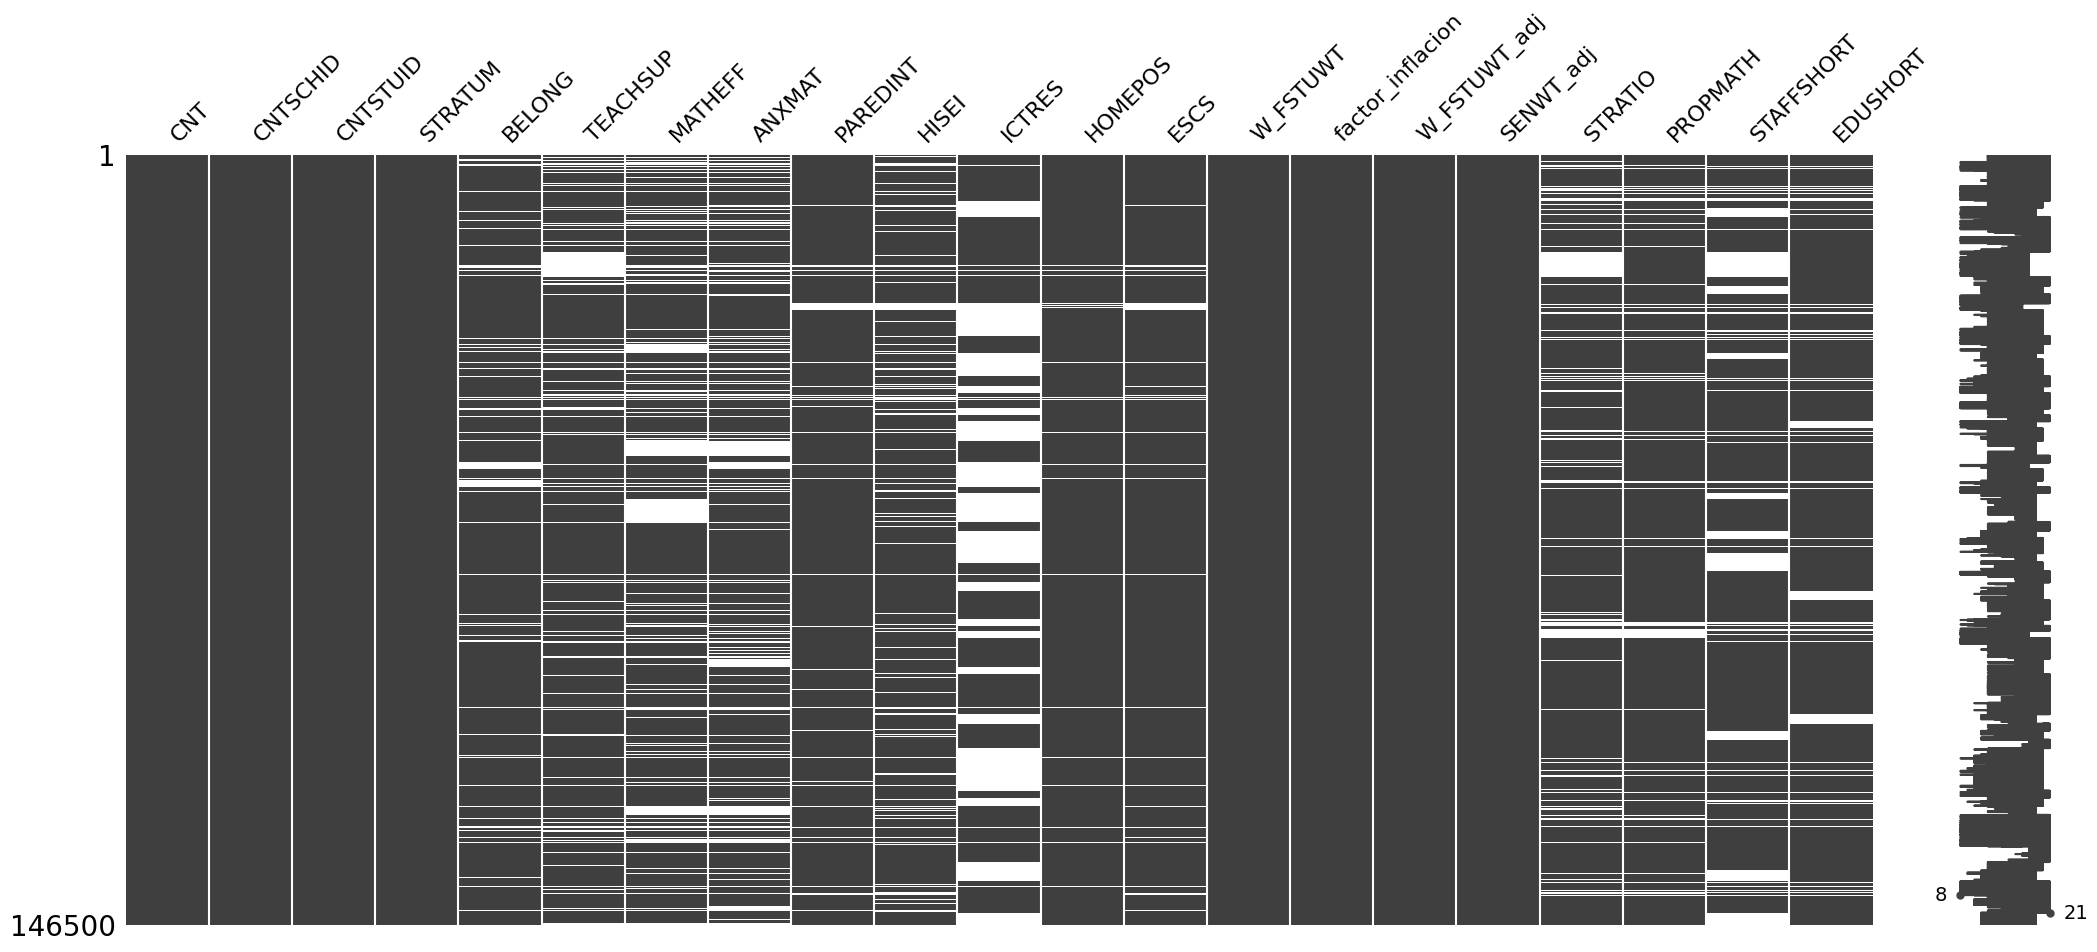

In [ ]:
#Matriz de nulos
msno.matrix(df_muestra_global)

In [ ]:
#TODO Desarrollar conclusiones del numero de nulos en ICTRES  y conclusiones del mapa de calor

Alto porcentaje de nulos en ICTRES, calculamos el porcentaje relatrivo de nulos por cada pais porque veo que hay bloques enteros blancos

In [134]:
#Se calcula y almacena  el porcentaje de nulos de ICTRES agrupados por pais
nulos_ictres_pais = (
    df_muestra_global['ICTRES']
    .isna()                                      # Convierte a True (nulo) o False (válido)
    .groupby(df_muestra_global['CNT'])           # Se realiza la agrupacion por pais
    .mean() * 100                                # La media de booleanos da la proporción * 100
)

#Se guarda en un nuevo dataframe el numero de nulos agrupados
df_nulos_ictres = nulos_ictres_pais.reset_index(name='Porcentaje_Nulos_ICTRES')
#Se ordena de mayor a menor los paises con mas nulos
df_nulos_ictres = df_nulos_ictres.sort_values('Porcentaje_Nulos_ICTRES', ascending=False)

print("Paises con mayor cantidad de nulos de ICTRES")
display(df_nulos_ictres.head(5))

Paises con mayor cantidad de nulos de ICTRES


,CNT,Porcentaje_Nulos_ICTRES
5,BEL,100.00
4,AUT,100.00
13,CRI,100.00
10,CHE,100.00
14,CZE,100.00


Se comprueba que existen varios paises en los que el indice derivado `ICTRES` es completamente nulo. Para tomar una decision respecto a la imputacion de dichos valores, se calculará el numero de paises totales en lo que no existen datos para el indice

In [133]:
paises_nulos_ictres_full=df_nulos_ictres[df_nulos_ictres['Porcentaje_Nulos_ICTRES']==100].value_counts().sum()

print(f'--- Número de paises con el 100% de nulos en ICTRES: {paises_nulos_ictres_full} ---')

--- Número de paises con el 100% de nulos en ICTRES: 33 ---


La OCDE permite a los países elegir si quieren pagar e invertir tiempo extra en pasarle a sus alumnos las preguntas específicas sobre ordenadores, internet y uso de pantallas.

En la edición de PISA 2022, el Cuestionario de Familiaridad con las TIC (ICTQ) fue un módulo internacional opcional en el que solo participaron 54 de los 81 países y economías evaluados. Es decir 27 paises decidieron no participar.

<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  "The optional PISA 2022 questionnaire on information and communication technology (ICT) was administered to 54 out of the
81 participating countries and economies" (PISA 2022 Results Volume V, p.212)
</div>

**Procedimiento con `ICTRES`:**

Dado que se quiere realziar un estudio global, manteniendo la mayor cantidad de paises posibles, la opcion mas lógica sera eliminar el indice derivado ICTRES dado que se pueden imputar nulos de paises enteros

In [ ]:
#Se elimina la columna del indicador derivado ICTRES directamente en el dataframe global
df_muestra_global.drop(columns='ICTRES', inplace=True)


<table width="100%" style="border:none; text-align:center;">
  <tr>
    <td style="border:none;"><hr></td>
    <td style="border:none; white-space:nowrap; padding:0 10px;"> <strong>Imputación multivariante<strong>
</td>
    <td style="border:none;"><hr></td>
  </tr>
</table>


<Axes: >

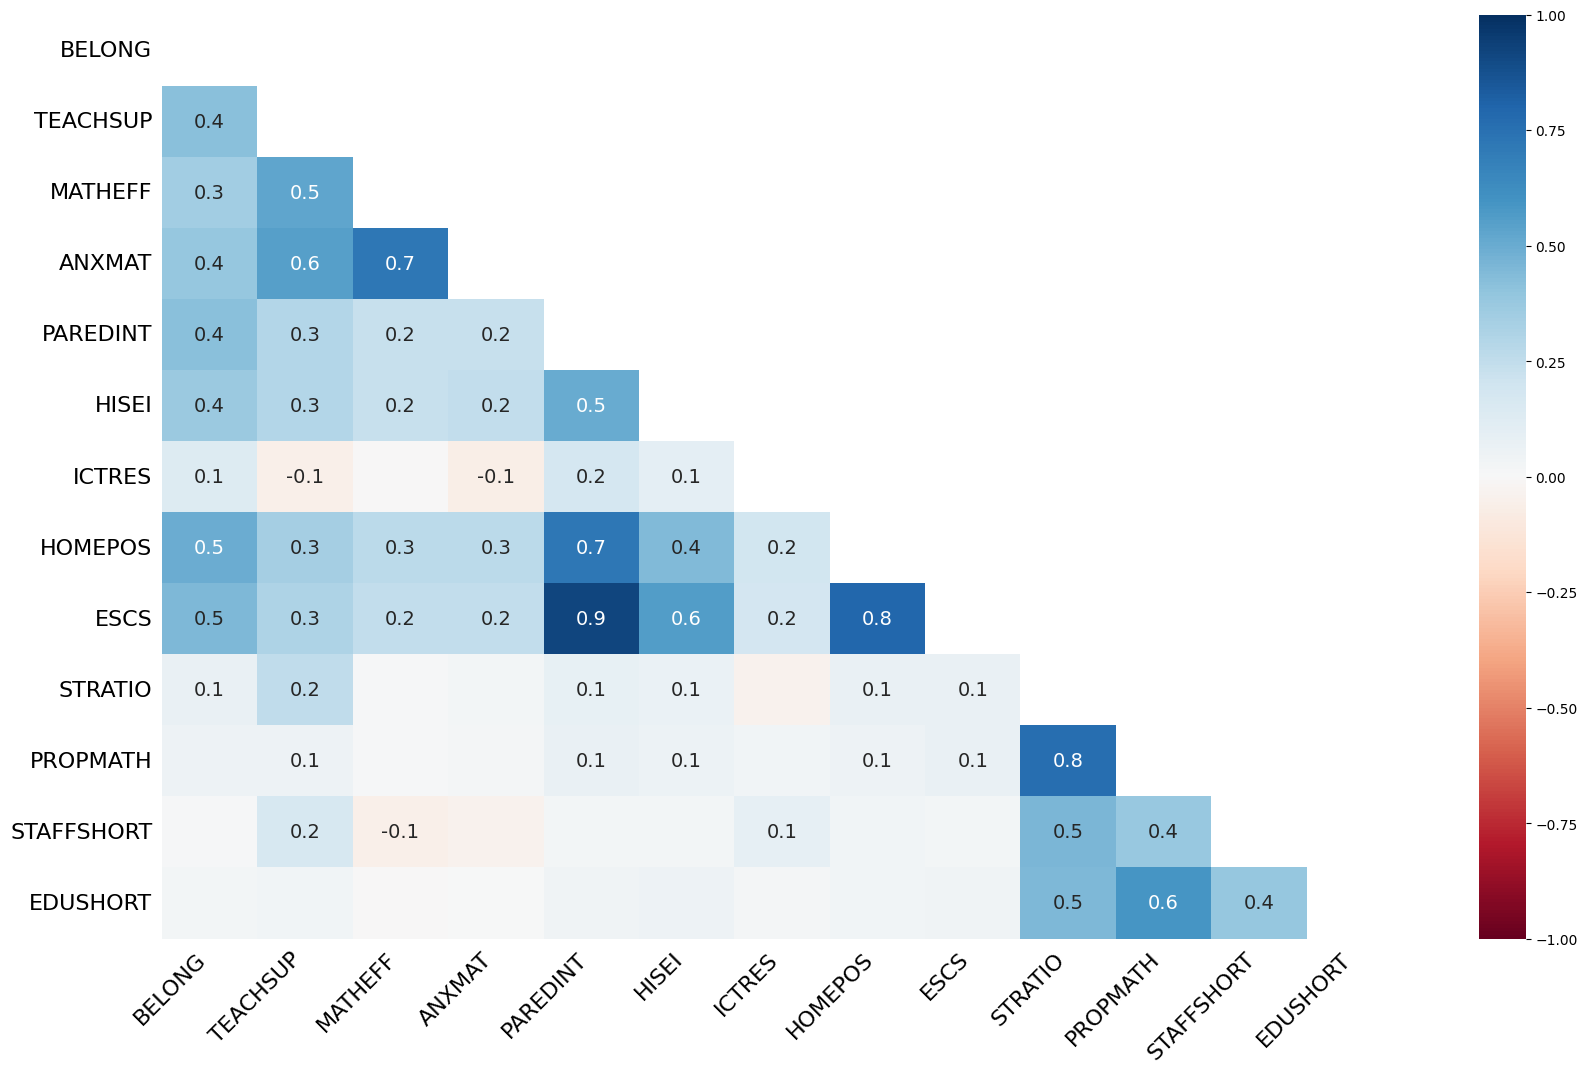

In [135]:
#Mapa de calor 
msno.heatmap(df_muestra_global)


El análisis con missingno revelá fuertes correlaciones de nulidad (hasta 0.9).
Se puede concluir entonces que nuestros algunos de nuestros datos no son MCAR (Missing Completely At Random) es decir, nulos al azar , sino MAR (Missing At Random ) condicionado a otras variables.


* `ESCS`, `PAREDINT` y `HOMEPOS` (0.7 a 0.9) :

    * Si un alumno no sabe qué nivel de estudios tienen sus padres (PAREDINT), se agobia y deja en blanco todo el bloque de preguntas sobre el dinero de su familia, las posesiones de su casa (HOMEPOS) y, en consecuencia, la OCDE no puede calcular su estatus social (ESCS).

* `STRATIO` , `PROPMATH` (0.8) :

    * Si director decidió saltarse la sección de Recursos Humanos (dejando en blanco la proporción de profesores de mates), también dejó en blanco el ratio general de alumnos por profesor

Debido a todo lo anterior se concluye que no se puede depender de la imputacion de nulos mediante el uso de la media general, pues se romperia la varizana de los datos. Se opta por una **imputación multivariante**, resolviendo el valor del nulo mediante la observacion de las instancias de otras variables presentes que tengan correlacion

In [146]:
#Se guarda en un array el nombre de las columnas a imputar los nulos
columnas_a_imputar=[col for col in df_muestra_global.columns if df_muestra_global[col].isnull().any()]
print(columnas_a_imputar)

['BELONG', 'TEACHSUP', 'MATHEFF', 'ANXMAT', 'PAREDINT', 'HISEI', 'HOMEPOS', 'ESCS', 'STRATIO', 'PROPMATH', 'STAFFSHORT', 'EDUSHORT']


In [147]:
#Se instancia el imputador multivariable
imputador_mice = IterativeImputer(
    estimator=Ridge(), 
    max_iter=10, 
    random_state=42, 
    add_indicator=True # Esto crea una columna extra avisando al modelo de que el dato fue imputado (muy pro)
)

In [148]:
#Se realiza la imputacion
df_imputado_array = imputador_mice.fit_transform(df_muestra_global[columnas_a_imputar])

c:\Users\victo\.conda\envs\tfm_env\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.032613069668514e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\victo\.conda\envs\tfm_env\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.609638347754299e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\victo\.conda\envs\tfm_env\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.182370609370992e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\victo\.conda\envs\tfm_env\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.904539873175963e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users

In [ ]:
#Se construye un dataframe limpio en el que se indica si el dato es original o imputado
df_limpio = pd.DataFrame(
    df_imputado_array, 
    columns=columnas_a_imputar + [f'{col}_missing' for col in columnas_a_imputar],
    index=df_muestra_global.index
)

In [150]:
#Se actualiza el dataframe global con los valores nulos imputados
for col in columnas_a_imputar:
    df_muestra_global[col] = df_limpio[col]

In [157]:
assert df_muestra_global.isnull().sum().sum() == 0,\
'Error!: Todavía quedan valores nulos a imputar'


In [163]:
#Se guarda en formato parquet el dataframe que contiene la submuestra con los nulos imputados
parquet_muestra_limpio = os.path.join(ruta_datos_intermedios, 'pisa22_submuestra_global_limpio.parquet')
df_muestra_global.to_parquet(parquet_muestra_limpio, engine='pyarrow', index=False)

In [164]:
df_muestra_global

,CNT,CNTSCHID,CNTSTUID,STRATUM,BELONG,TEACHSUP,MATHEFF,ANXMAT,PAREDINT,HISEI,HOMEPOS,ESCS,W_FSTUWT,factor_inflacion,W_FSTUWT_adj,SENWT_adj,STRATIO,PROPMATH,STAFFSHORT,EDUSHORT
0,ALB,800282,800001,ALB03,-0.23,1.56,-1.44,0.54,14.50,73.91,1.60,1.11,3.16,5.00,15.79,2.84,11.08,0.11,-0.01,-0.28
1,ALB,800242,800003,ALB01,-0.03,0.05,-0.31,0.18,12.00,58.26,0.23,-0.19,7.84,5.00,39.19,7.04,13.24,0.12,0.17,0.18
2,ALB,800172,800007,ALB04,-0.45,1.56,2.14,-0.71,16.00,86.72,0.37,1.09,4.26,5.00,21.30,3.83,8.13,0.13,-1.46,-1.42
3,ALB,800040,800015,ALB03,-0.11,0.15,-0.53,0.29,16.00,45.72,-0.77,-0.17,4.41,5.00,22.07,3.96,17.47,0.15,-0.18,0.11
4,ALB,800123,800024,ALB06,0.33,1.56,0.89,1.01,12.00,28.84,-0.11,-0.88,5.89,3.50,20.62,3.70,17.88,0.09,-1.46,-1.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146495,UZB,86000071,86007478,UZB20,1.15,1.56,-1.36,0.54,16.00,29.16,-0.37,-0.31,52.65,3.00,157.94,1.71,19.02,0.10,-0.15,-0.44
146496,UZB,86000054,86007480,UZB18,0.74,1.56,-0.35,-0.43,16.00,27.91,-2.51,-1.24,60.90,4.67,284.18,3.07,12.40,0.06,0.32,0.63
146497,UZB,86000002,86007483,UZB23,-0.20,1.56,0.66,1.24,12.00,30.11,-1.77,-1.57,77.08,2.00,154.15,1.67,18.27,0.07,0.33,0.50
146498,UZB,86000056,86007485,UZB01,-0.28,-0.33,-1.18,0.83,16.00,81.92,-0.98,0.42,65.64,1.00,65.64,0.71,14.79,0.10,-0.08,-0.24
